In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

train_images = np.load('../data/processed/train_images.npy')
train_labels = np.load('../data/processed/train_labels.npy')
test_images = np.load('../data/processed/test_images.npy')
test_labels = np.load('../data/processed/test_labels.npy')


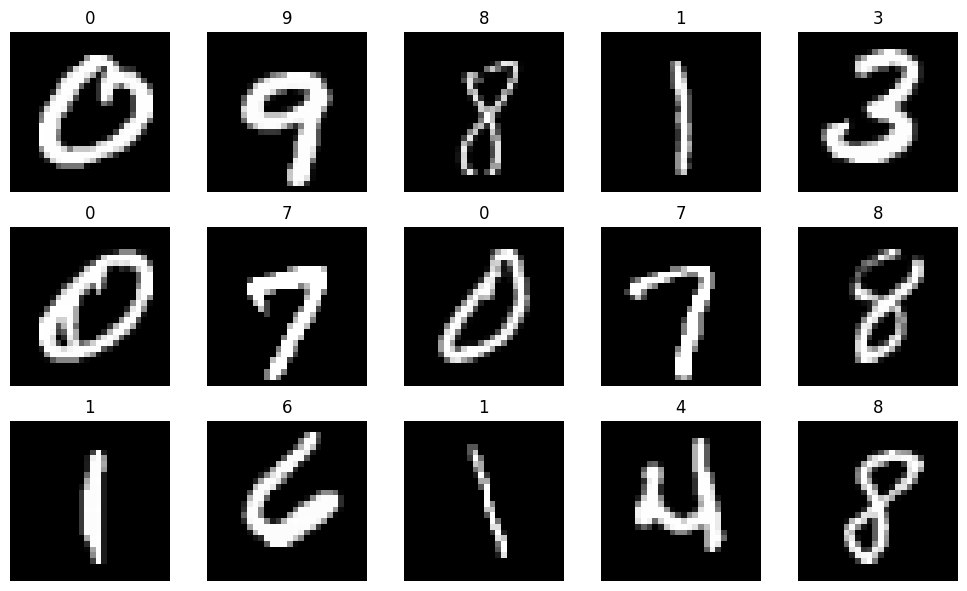

In [55]:
n = 15
total = len(train_images)
random_indices = np.random.choice(total, n, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for i, ax in enumerate(axes.flat):
    idx = random_indices[i]
    ax.imshow(train_images[idx], cmap='gray')
    ax.set_title(str(train_labels[idx]))
    ax.axis('off')

plt.tight_layout()
plt.show()

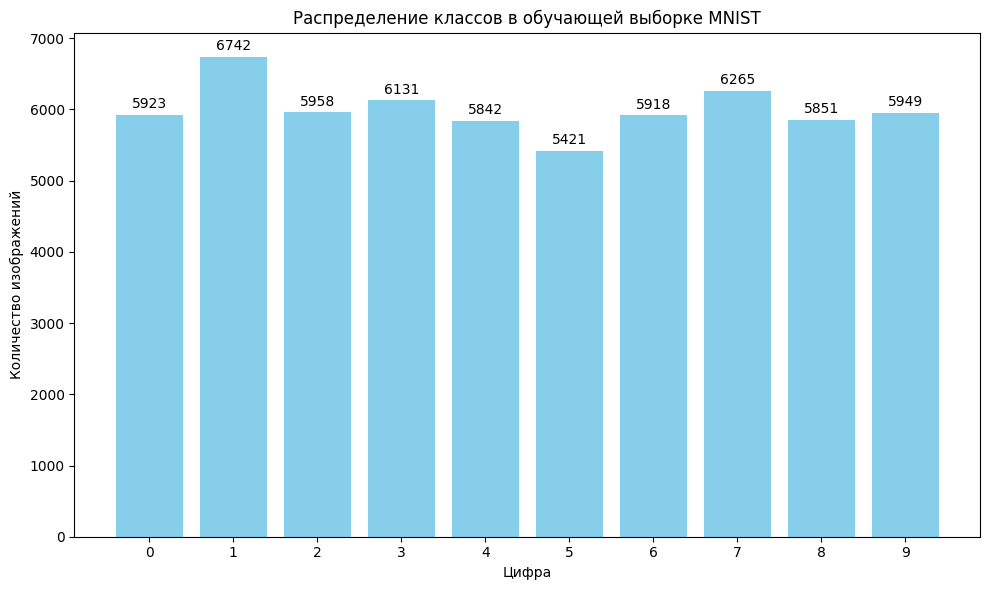

In [56]:
unique_train, counts_train = np.unique(train_labels, return_counts=True)

plt.figure(figsize=(10, 6))
bars = plt.bar(unique_train, counts_train, color='skyblue')
plt.xticks(unique_train)
plt.xlabel('Цифра')
plt.ylabel('Количество изображений')
plt.title('Распределение классов в обучающей выборке MNIST')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50, f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

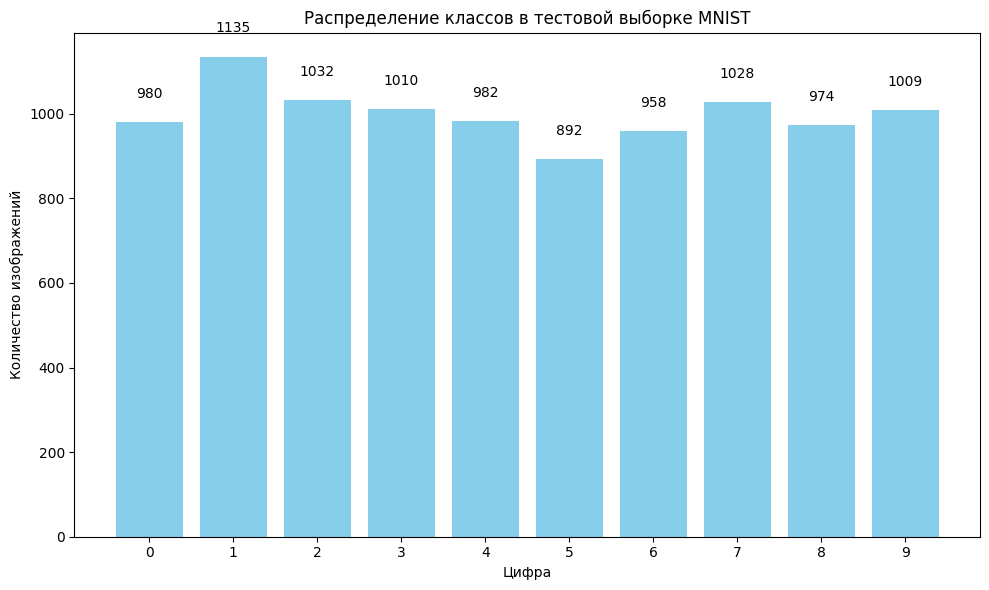

In [57]:
unique_test, counts_test = np.unique(test_labels, return_counts=True)

plt.figure(figsize=(10, 6))
bars = plt.bar(unique_test, counts_test, color='skyblue')
plt.xticks(unique_test)
plt.xlabel('Цифра')
plt.ylabel('Количество изображений')
plt.title('Распределение классов в тестовой выборке MNIST')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50, f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

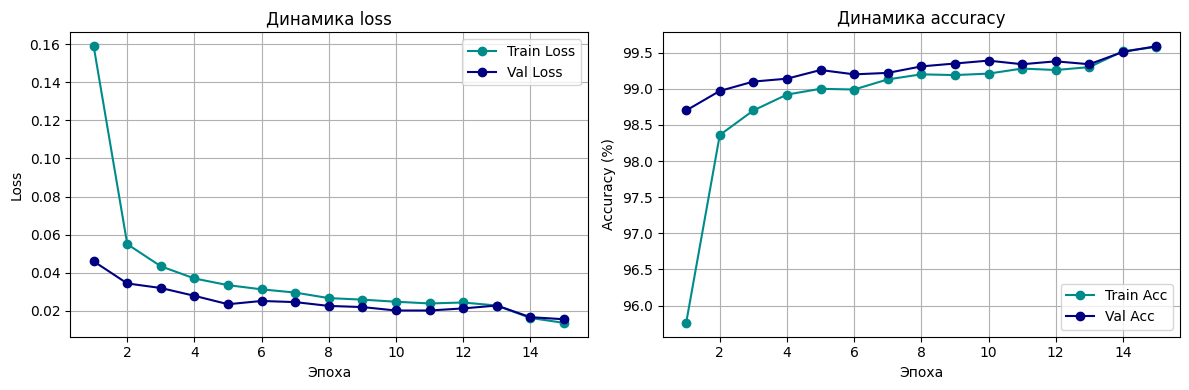

In [58]:
epochs = list(range(1, 16))

train_loss = [0.1589, 0.0550, 0.0434, 0.0370, 0.0335, 0.0313, 0.0296, 0.0267,
              0.0259, 0.0248, 0.0239, 0.0244, 0.0228, 0.0163, 0.0137]

val_loss = [0.0460, 0.0344, 0.0320, 0.0279, 0.0235, 0.0252, 0.0246, 0.0226,
            0.0220, 0.0202, 0.0202, 0.0213, 0.0228, 0.0167, 0.0156]

train_acc = [95.76, 98.36, 98.70, 98.92, 99.00, 98.99, 99.13, 99.20,
             99.19, 99.21, 99.28, 99.26, 99.30, 99.52, 99.58]

val_acc = [98.70, 98.97, 99.10, 99.14, 99.26, 99.20, 99.22, 99.31,
           99.35, 99.39, 99.34, 99.38, 99.34, 99.51, 99.59]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'o-', color='darkcyan', label='Train Loss')
plt.plot(epochs, val_loss, 'o-', color='navy', label='Val Loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Динамика loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'o-', color='darkcyan', label='Train Acc')
plt.plot(epochs, val_acc, 'o-', color='navy', label='Val Acc')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy (%)')
plt.title('Динамика accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [59]:
import numpy as np
import pandas as pd

class SoftmaxRegression:
    def __init__(self, learning_rate=1.13, tolerance=0.00001, max_iter=1000):
        self.learning_rate = learning_rate
        self.tolerance = tolerance
        self.max_iter = max_iter

    def _softmax(self, predictions):
        predictions = predictions - np.max(predictions, axis=1, keepdims=True)
        exp = np.exp(predictions)
        return exp / np.sum(exp, axis=1, keepdims=True)

    def fit(self, X, y):
        n_classes = len(np.unique(y))
        n_samples, n_features = X.shape
        one_hot_y = pd.get_dummies(y).to_numpy()
        self.bias = np.zeros(n_classes)
        self.weights = np.zeros((n_features, n_classes))
        previous_db = np.zeros(n_classes)
        previous_dw = np.zeros((n_features, n_classes))

        for _ in range(self.max_iter):
            y_pred_linear = X @ self.weights + self.bias
            y_pred_softmax = self._softmax(y_pred_linear)
            error = y_pred_softmax - one_hot_y
            db = 1 / n_samples * np.sum(error, axis=0)
            dw = 1 / n_samples * X.T @ error
            self.bias -= self.learning_rate * db
            self.weights -= self.learning_rate * dw
            abs_db_reduction = np.abs(db - previous_db)
            abs_dw_reduction = np.abs(dw - previous_dw)
            if np.mean(abs_db_reduction) < self.tolerance and np.mean(abs_dw_reduction) < self.tolerance:
                break
            previous_db = db
            previous_dw = dw

    def predict(self, X_test):
        y_pred_linear = X_test @ self.weights + self.bias
        y_pred_softmax = self._softmax(y_pred_linear)
        return np.argmax(y_pred_softmax, axis=1)

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train_flat = train_images.reshape(train_images.shape[0], -1).astype(np.float32) / 255.0
X_test_flat = test_images.reshape(test_images.shape[0], -1).astype(np.float32) / 255.0

mean = X_train_flat.mean(axis=0)
std = X_train_flat.std(axis=0)
std[std == 0] = 1
X_train_scaled = (X_train_flat - mean) / std
X_test_scaled = (X_test_flat - mean) / std

model_my = SoftmaxRegression()
model_my.fit(X_train_scaled, train_labels)
y_pred_my = model_my.predict(X_test_scaled)

model_sk = LogisticRegression(max_iter=1000)
model_sk.fit(X_train_scaled, train_labels)
y_pred_sk = model_sk.predict(X_test_scaled)

print(f"My Softmax: {accuracy_score(test_labels, y_pred_my):.4f}")
print(f"Sklearn: {accuracy_score(test_labels, y_pred_sk):.4f}")

My Softmax: 0.9204
Sklearn: 0.9216


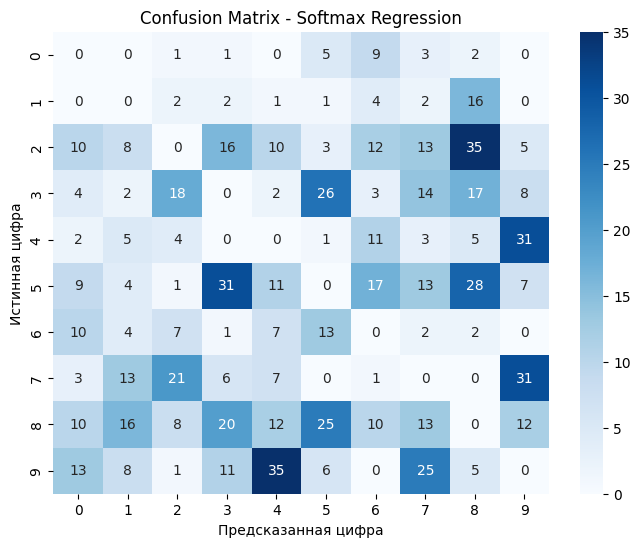

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(test_labels, y_pred_my)
np.fill_diagonal(cm, 0)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Предсказанная цифра')
plt.ylabel('Истинная цифра')
plt.title('Confusion Matrix - Softmax Regression')
plt.show()

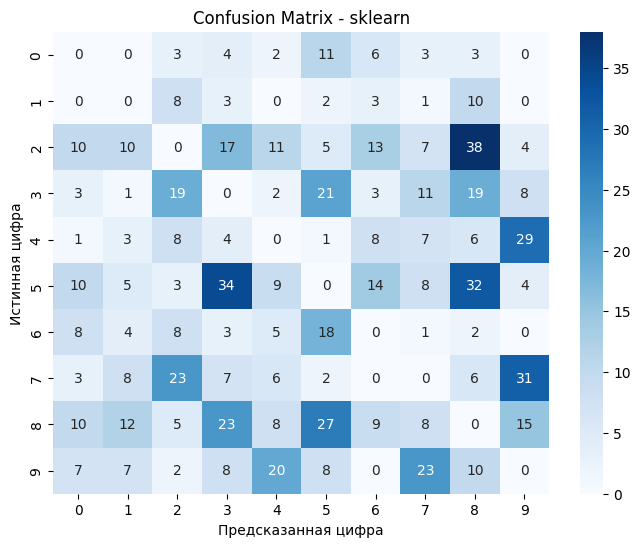

In [62]:
cm = confusion_matrix(test_labels, y_pred_sk)
np.fill_diagonal(cm, 0)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Предсказанная цифра')
plt.ylabel('Истинная цифра')
plt.title('Confusion Matrix - sklearn')
plt.show()

In [63]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3136, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.classifier(x)
        return x

In [64]:
model = MNISTModel()
model.load_state_dict(torch.load("best_model.pth", map_location=torch.device('cpu')))
model.eval()

X_test_tensor = torch.tensor(test_images, dtype=torch.float32).unsqueeze(1) / 255.0

y_pred_cnn = []
with torch.no_grad():
    for i in range(0, len(X_test_tensor), 64):
        outputs = model(X_test_tensor[i:i+64])
        _, predicted = torch.max(outputs, 1)
        y_pred_cnn.extend(predicted.numpy())

print(f"Точность: {(np.array(y_pred_cnn) == test_labels).mean():.4f}")

Точность: 0.9954


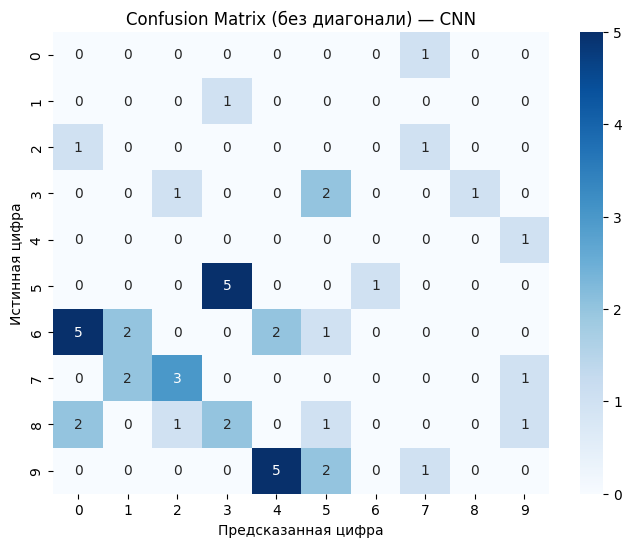

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_labels, y_pred_cnn)
np.fill_diagonal(cm, 0)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Предсказанная цифра')
plt.ylabel('Истинная цифра')
plt.title('Confusion Matrix — CNN')
plt.show()